
# EXPLORATORY DATA ANALYSIS (EDA)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load cleaned dataset
df = pd.read_csv("cleaned_seattle_weather.csv")

# Check dataset
print(df.head())

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-03            0.8      11.7       7.2   2.3     rain
2  2012-01-05            1.3       8.9       2.8   6.1     rain
3  2012-01-06            2.5       4.4       2.2   2.2     rain
4  2012-01-07            0.0       7.2       2.8   2.3     rain


In [3]:
# Set Plot Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)



#### 1. Dataset Overview


In [4]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)
print(df.info())

print("\n")
print("="*60)
print("FIRST 5 RECORDS")
print("="*60)
print(df.head())

print("\n")
print("="*60)
print("LAST 5 RECORDS")
print("="*60)
print(df.tail())


DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 1233 entries, 0 to 1232
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1233 non-null   str    
 1   precipitation  1233 non-null   float64
 2   temp_max       1233 non-null   float64
 3   temp_min       1233 non-null   float64
 4   wind           1233 non-null   float64
 5   weather        1233 non-null   str    
dtypes: float64(4), str(2)
memory usage: 57.9 KB
None


FIRST 5 RECORDS
         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-03            0.8      11.7       7.2   2.3     rain
2  2012-01-05            1.3       8.9       2.8   6.1     rain
3  2012-01-06            2.5       4.4       2.2   2.2     rain
4  2012-01-07            0.0       7.2       2.8   2.3     rain


LAST 5 RECORDS
            date  precipitation  temp_max  temp_min  wind we

#### 2. Statistical Summary


In [5]:
print("\n")
print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print(df.describe(include="all"))



STATISTICAL SUMMARY
              date  precipitation     temp_max     temp_min         wind  \
count         1233    1233.000000  1233.000000  1233.000000  1233.000000   
unique        1233            NaN          NaN          NaN          NaN   
top     2012-01-01            NaN          NaN          NaN          NaN   
freq             1            NaN          NaN          NaN          NaN   
mean           NaN       0.783942    17.171290     8.437470     2.990349   
std            NaN       1.568300     7.547474     5.172796     1.220587   
min            NaN       0.000000    -1.600000    -7.100000     0.400000   
25%            NaN       0.000000    11.100000     4.400000     2.200000   
50%            NaN       0.000000    16.700000     8.900000     2.800000   
75%            NaN       0.500000    22.800000    12.800000     3.700000   
max            NaN       6.900000    35.600000    18.300000     6.600000   

       weather  
count     1233  
unique       5  
top        sun

#### 3. Check Unique Values


In [6]:
print("\nUnique Values in Each Column")
print(df.nunique())




Unique Values in Each Column
date             1233
precipitation      28
temp_max           66
temp_min           55
wind               63
weather             5
dtype: int64


#### 4. Correlation Heatmap


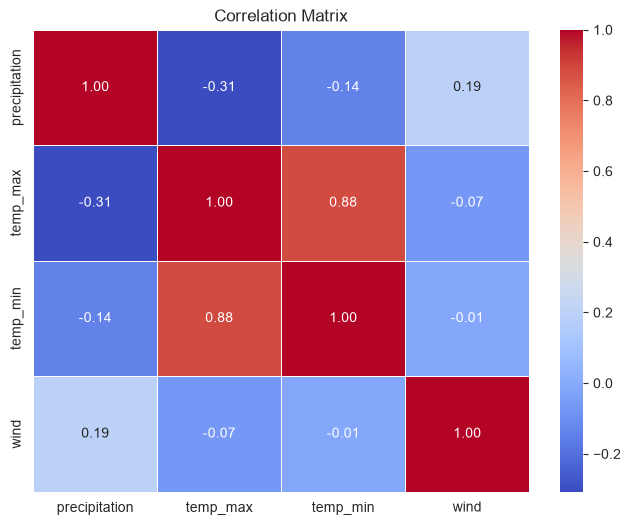

In [7]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()


#### 5. Weather Class Distribution


C:\Users\artim\AppData\Local\Temp\ipykernel_19844\1497104146.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


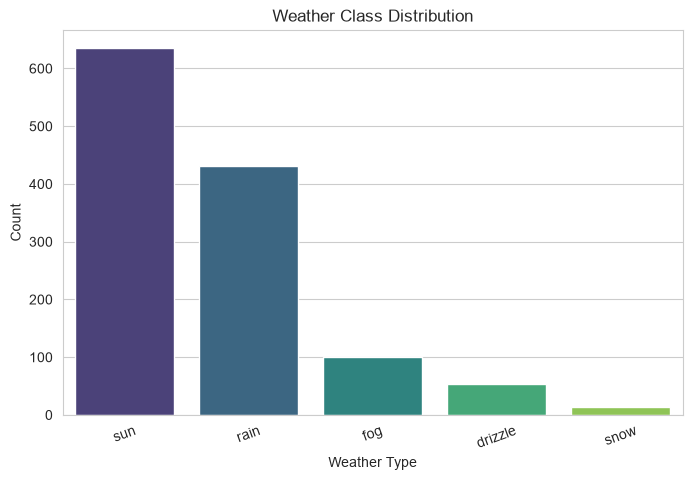

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="weather",
    order=df["weather"].value_counts().index,
    palette="viridis"
)

plt.title("Weather Class Distribution")
plt.xlabel("Weather Type")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()



#### 6. Temperature Distribution


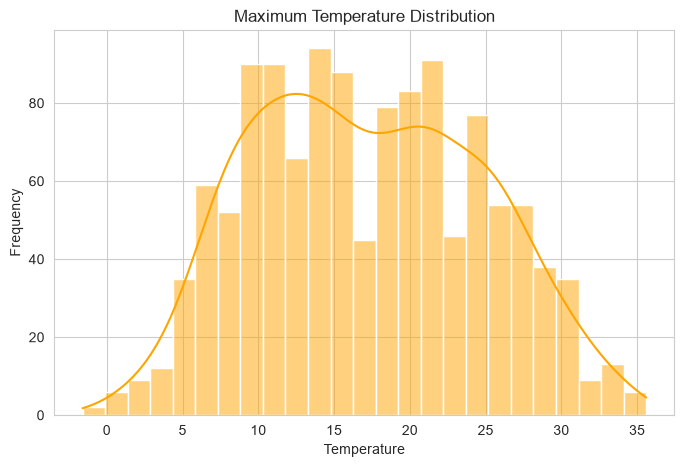

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["temp_max"], bins=25, kde=True, color="orange")

plt.title("Maximum Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()



#### 7. Minimum Temperature Distribution


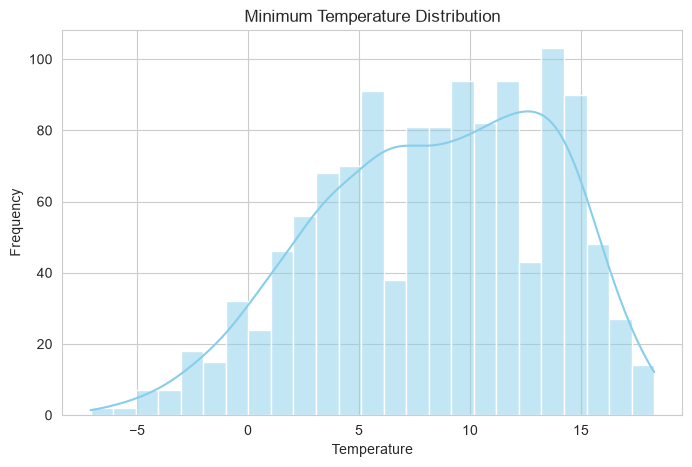

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["temp_min"], bins=25, kde=True, color="skyblue")

plt.title("Minimum Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()



#### 8. Rainfall Distribution


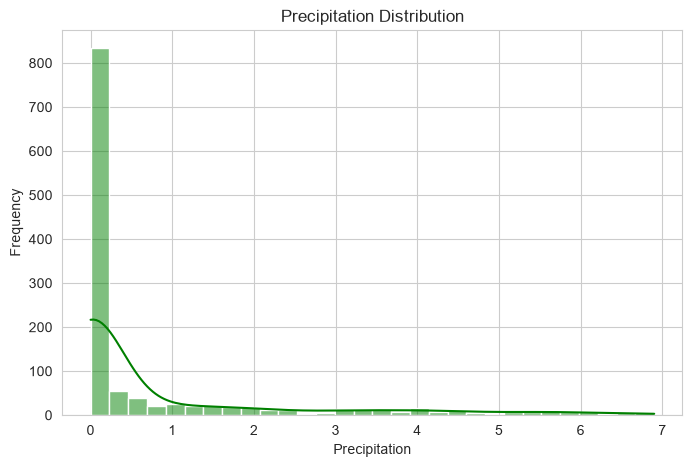

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["precipitation"], bins=30, kde=True, color="green")

plt.title("Precipitation Distribution")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")
plt.show()


#### 9. Wind Speed Distribution


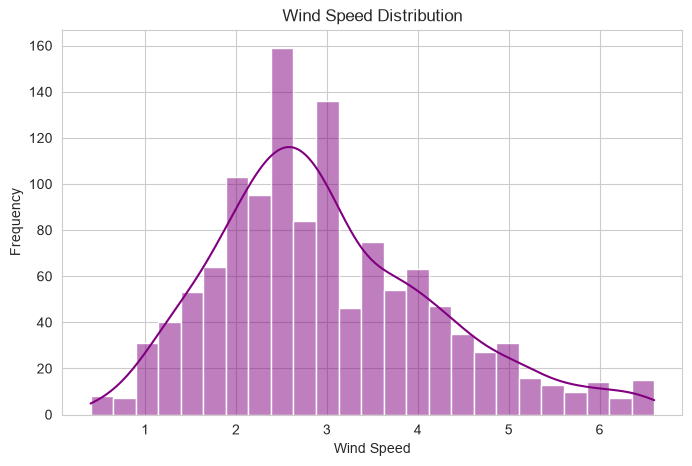

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["wind"], bins=25, kde=True, color="purple")

plt.title("Wind Speed Distribution")
plt.xlabel("Wind Speed")
plt.ylabel("Frequency")
plt.show()



#### 10. Boxplots for Outlier Detection


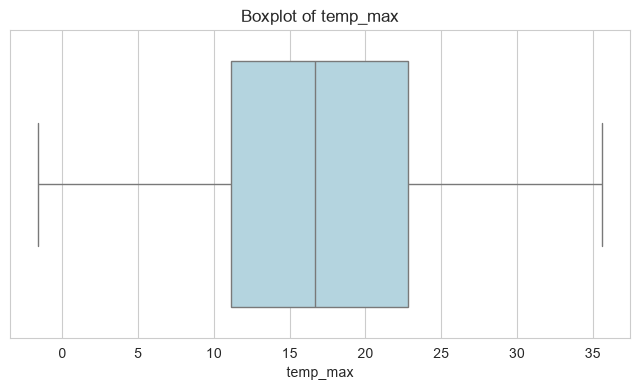

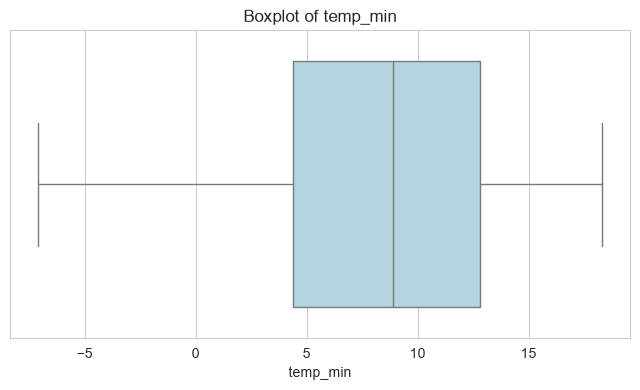

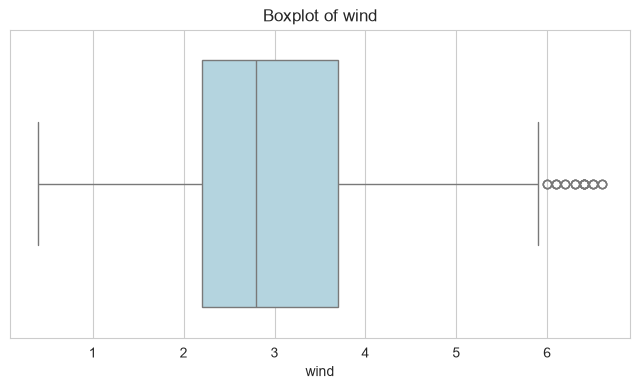

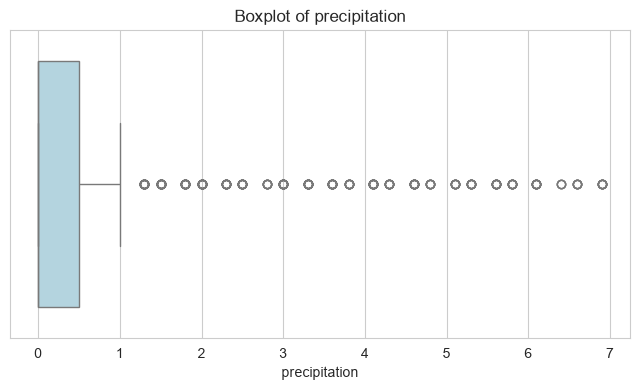

In [13]:
columns = ["temp_max", "temp_min", "wind", "precipitation"]

for col in columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col], color="lightblue")
    plt.title(f"Boxplot of {col}")
    plt.show()


#### 11. Pairplot


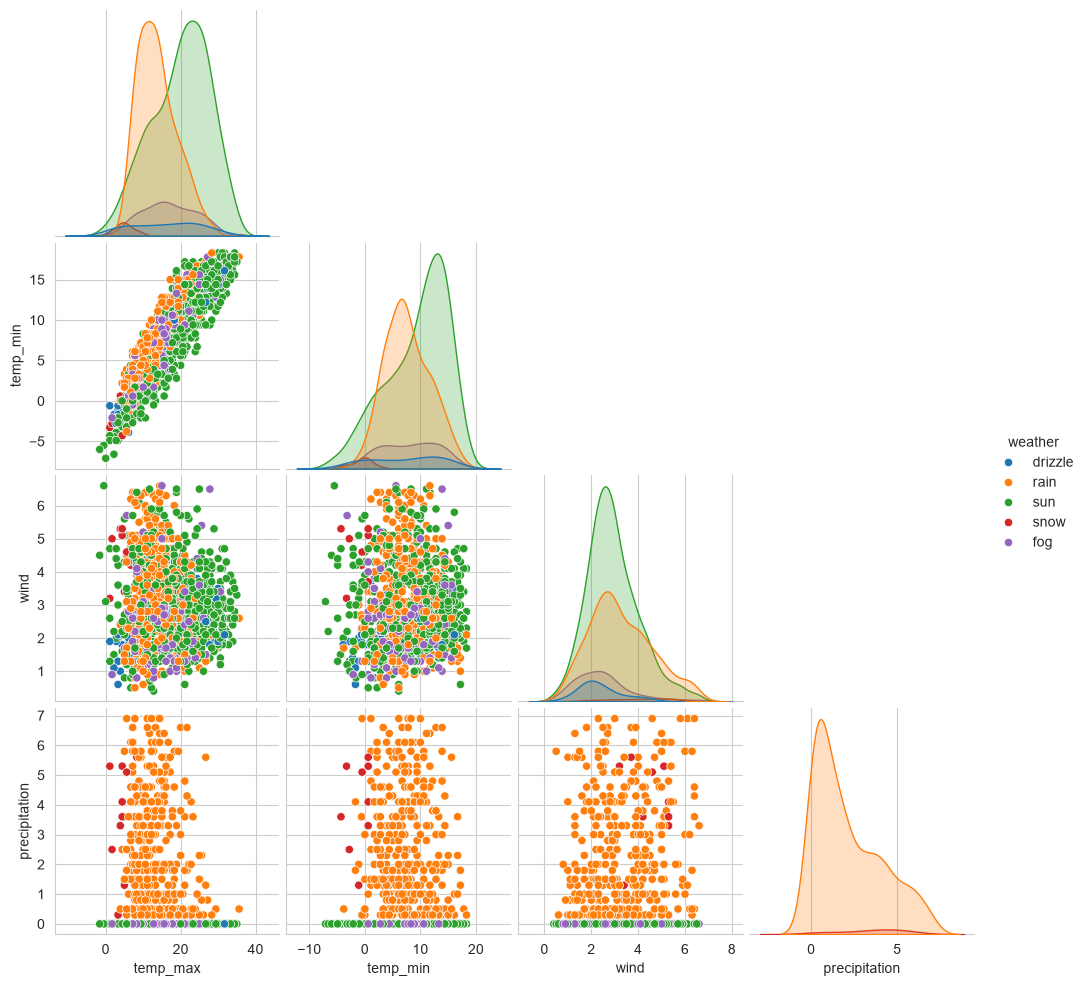

In [14]:
sns.pairplot(
    df,
    vars=["temp_max", "temp_min", "wind", "precipitation"],
    hue="weather",
    corner=True
)

plt.show()
